# Denoising Autoencoder on MNIST

## Library Imports and Seeding

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Input, Model
from tensorflow.keras.datasets import mnist

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

## 1. Load & Preprocess the MNIST Dataset

In [2]:
(x_train, _), (x_test, _) = mnist.load_data()

print("Train images:", x_train.shape)
print("Test images:", x_test.shape)
print("Pixel dtype :", x_train.dtype, "range:", x_train.min(), "-", x_train.max())

Train images: (60000, 28, 28)
Test images: (10000, 28, 28)
Pixel dtype : uint8 range: 0 - 255


In [3]:
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32")  / 255.0

x_train = np.expand_dims(x_train, axis=-1)
x_test  = np.expand_dims(x_test,  axis=-1)

print("Train shape after reshape:", x_train.shape)
print("New pixel range:", float(x_train.min()), "-", float(x_train.max()))

Train shape after reshape: (60000, 28, 28, 1)
New pixel range: 0.0 - 1.0


**Insight — two preprocessing steps:**

1. **Normalisation to [0, 1].** Neural networks train better on small bounded inputs and **sigmoid** activation our output layer also outputs values in [0, 1]. That's why i've divided the data with 255 which was it's max value to make this data range between 0 and 1.
2. **Adding a dimension** (28, 28) to (28, 28, 1). Convolutional layers expect a 3D dimension. That's why i've used expand_dims() function.

## 2. Add Artificial Noise

In [4]:
noise_factor = 0.5

x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy  = x_test  + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)

x_train_noisy = np.clip(x_train_noisy, 0.0, 1.0)
x_test_noisy  = np.clip(x_test_noisy,  0.0, 1.0)

print("Noisy train shape:", x_train_noisy.shape)
print("Noisy pixel range:", float(x_train_noisy.min()), "-", float(x_train_noisy.max()))

Noisy train shape: (60000, 28, 28, 1)
Noisy pixel range: 0.0 - 1.0


**Insight:**

- I've added **additive Gaussian noise** each pixel gets a randomly noised and then scaled by noise_factor. Higher noise = difficult to identify.
- **Clipping**: some pixels range below 0 or above 1 which is meaningless for an image so there are removed(clipped).

# 3. Sanity Check(Clean and Noisy Image)

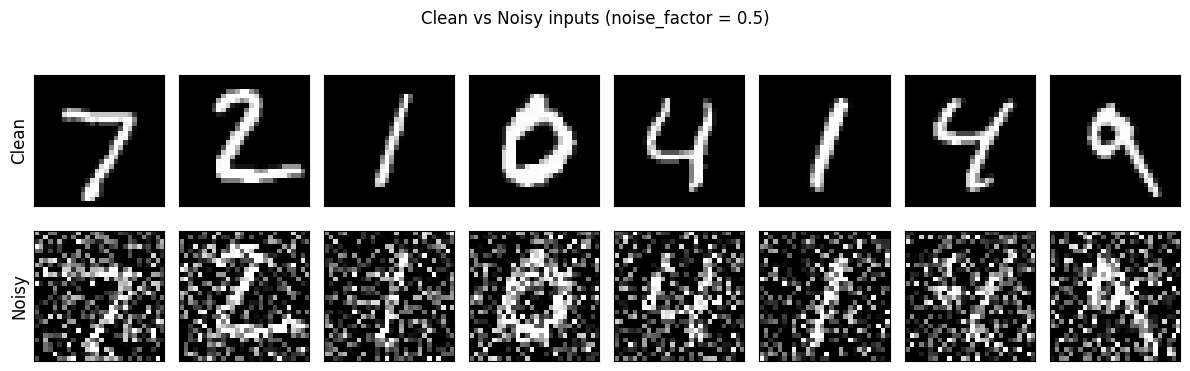

In [5]:
n = 8
plt.figure(figsize=(12, 4))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap="gray")
    ax.set_xticks([]); ax.set_yticks([])
    if i == 0:
        ax.set_ylabel("Clean", fontsize=12)

    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].reshape(28, 28), cmap="gray")
    ax.set_xticks([]); ax.set_yticks([])
    if i == 0:
        ax.set_ylabel("Noisy", fontsize=12)

plt.suptitle("Clean vs Noisy inputs (noise_factor = 0.5)")
plt.tight_layout()
plt.show()

## 4. Build the Denoising Autoencoder

In [6]:
input_img = Input(shape=(28, 28, 1))

x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(input_img)
x = layers.MaxPooling2D((2, 2), padding="same")(x)
x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(x)
encoded = layers.MaxPooling2D((2, 2), padding="same")(x)

x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(encoded)
x = layers.UpSampling2D((2, 2))(x)
x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(x)
x = layers.UpSampling2D((2, 2))(x)
decoded = layers.Conv2D(1, (3, 3), activation="sigmoid", padding="same")(x)

autoencoder = Model(input_img, decoded, name="denoising_autoencoder")
autoencoder.summary()

Model: "denoising_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,353 (110.75 KB)

 Trainable params: 28,353 (110.75 KB)

 Non-trainable params: 0 (0.00 B)

**Insight — how the architecture forces denoising:**

- **Encoder (compression).** Conv2D + MaxPooling. They compresses the image and passes ahead.
- **The bottleneck** This focuses on minimise reconstruction error and denoising.
- **Decoder (reconstruction).** Conv2D + UpSampling it mirrors the encoder to rebuild a full image(output).
- **Sigmoid layer** Every output pixel is converted into [0, 1].

In [7]:
autoencoder.compile(optimizer="adam", loss="binary_crossentropy")

**Loss and Optimiser:**

- **Optimiser: Adam.** Adam is a robust adaptive and default Optimiser that needs little manual learning-rate tuning mostly used optimizer.
- **Loss: binary cross-entropy.** Because our output is between 0 and 1.

## 5. Train the Model

In [8]:
history = autoencoder.fit(
    x_train_noisy, x_train,
    epochs=20,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test),
)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 0.1711 - val_loss: 0.1175
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1143 - val_loss: 0.1096
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.1089 - val_loss: 0.1061
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1059 - val_loss: 0.1037
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1040 - val_loss: 0.1022
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1026 - val_loss: 0.1011
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.1014 - val_loss: 0.1003
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1005 - val_loss: 0.0993
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0998 - val_loss: 0.0988
Epoch 10/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0993 - val_loss: 0.0983
Epoch 11/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0988 - val_loss: 0.0979
Epoch 12/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/st

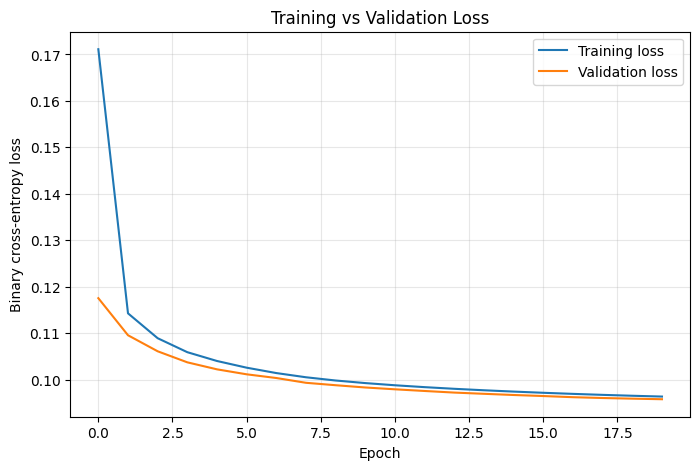

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"],     label="Training loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Binary cross-entropy loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Insights:**

- **Both curves fall and then flatten** -> it means that model is learning.
- **Both the lines are close** -> It means models is able to produce the correct denoised images

## 6. Generate Denoised Outputs on the Test Set

In [10]:
denoised_imgs = autoencoder.predict(x_test_noisy)
print("Denoised output shape:", denoised_imgs.shape)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Denoised output shape: (10000, 28, 28, 1)


# 7. Plotting
* Actual, Noisy Input, Denoised Output

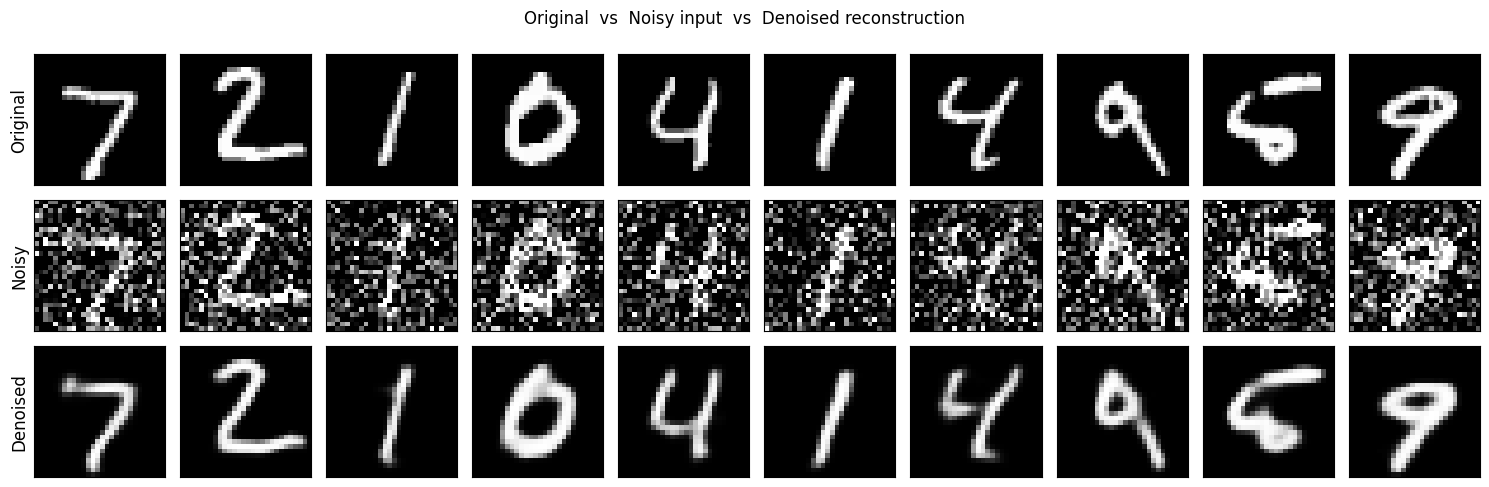

In [11]:
n = 10
plt.figure(figsize=(15, 5))
rows = [("Original", x_test), ("Noisy", x_test_noisy), ("Denoised", denoised_imgs)]
for r, (label, data) in enumerate(rows):
    for i in range(n):
        ax = plt.subplot(3, n, r * n + i + 1)
        plt.imshow(data[i].reshape(28, 28), cmap="gray")
        ax.set_xticks([]); ax.set_yticks([])
        if i == 0:
            ax.set_ylabel(label, fontsize=12)
plt.suptitle("Original  vs  Noisy input  vs  Denoised reconstruction")
plt.tight_layout()
plt.show()

**Insight**

- **Row 1 (Original):** Actual image
- **Row 2 (Noisy):** Images passed into the model noised images.
- **Row 3 (Denoised):** Model's output Model has remove the noised and given the images near to the actual image just a bit solfer and blurry.

**slightly softer / blurrier** This is the because model tries to erases every bit of noise which causes the blur and smoothness in image.

## 8. Evaluation - PSNR & SSIM

In [12]:
tf_x_test = tf.cast(x_test, tf.float32)
tf_x_test_noisy = tf.cast(x_test_noisy, tf.float32)
tf_denoised_imgs = tf.cast(denoised_imgs, tf.float32)

psnr_noisy = float(tf.reduce_mean(tf.image.psnr(tf_x_test, tf_x_test_noisy, max_val=1.0)))
psnr_denoised = float(tf.reduce_mean(tf.image.psnr(tf_x_test, tf_denoised_imgs, max_val=1.0)))

ssim_noisy = float(tf.reduce_mean(tf.image.ssim(tf_x_test, tf_x_test_noisy, max_val=1.0)))
ssim_denoised = float(tf.reduce_mean(tf.image.ssim(tf_x_test, tf_denoised_imgs, max_val=1.0)))

print(f"PSNR Noisy:{psnr_noisy:6.2f} -> Denoised:{psnr_denoised:6.2f}")
print(f"SSIM Noisy:{ssim_noisy:6.4f} -> Denoised:{ssim_denoised:6.4f}")

PSNR Noisy:  9.39 -> Denoised: 19.96
SSIM Noisy:0.4129 -> Denoised:0.8626


**Insight**

- **PSNR** Higher is better. It measures how close the reconstruction is to the original in raw image in pixal.
- **SSIM:** Higher is better. SSIM is said to be a matrix that states how good a image is as per the human vision.


## 9. Experiment — Using Different Noise Levels

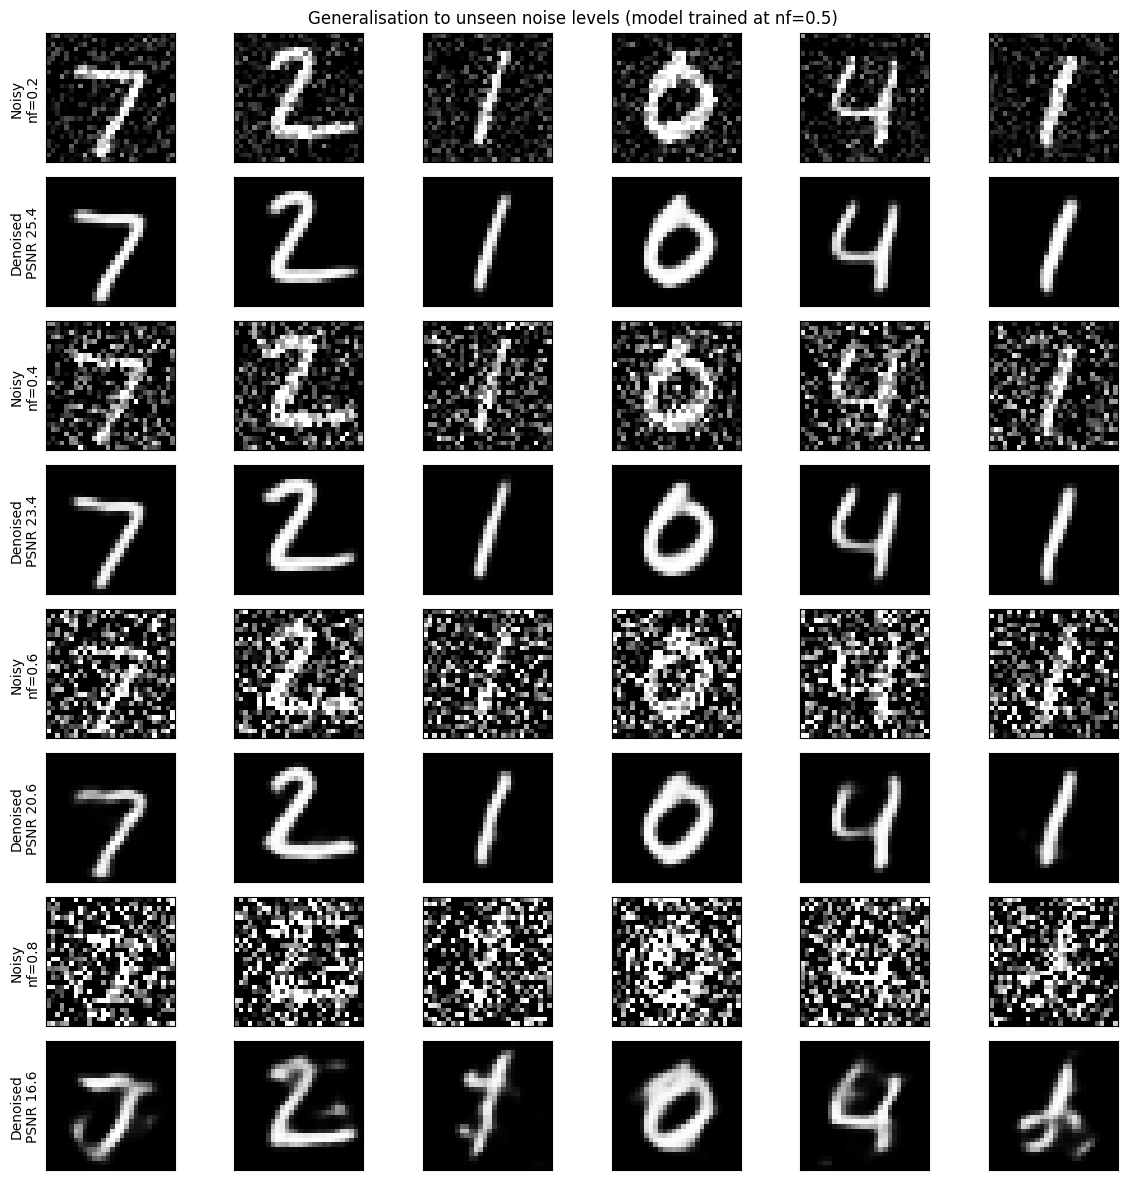

In [13]:
noise_levels = [0.2, 0.4, 0.6, 0.8]
n_show = 6

fig, axes = plt.subplots(len(noise_levels) * 2, n_show, figsize=(12, 12))
for r, nf in enumerate(noise_levels):
    sample = x_test[:n_show]
    noisy = np.clip(sample + nf * np.random.normal(size=sample.shape), 0.0, 1.0)
    recovered = autoencoder.predict(noisy, verbose=0)
    psnr_val  = float(tf.reduce_mean(tf.image.psnr(sample, recovered, max_val=1.0)))

    for i in range(n_show):
        axes[2*r,i].imshow(noisy[i].reshape(28, 28), cmap="gray")
        axes[2*r,i].set_xticks([]); axes[2*r, i].set_yticks([])
        axes[2*r+1,i].imshow(recovered[i].reshape(28, 28), cmap="gray")
        axes[2*r+1,i].set_xticks([]); axes[2*r + 1, i].set_yticks([])

    axes[2*r,0].set_ylabel(f"Noisy\nnf={nf}", fontsize=10)
    axes[2*r+1,0].set_ylabel(f"Denoised\nPSNR {psnr_val:.1f}", fontsize=10)

plt.suptitle("Generalisation to unseen noise levels (model trained at nf=0.5)")
plt.tight_layout()
plt.show()

**Insight**


- At **low noise (0.2–0.4)** the model works great the task is easier and the PSNR is highest.
- Around **0.6** model still works well.
- Near to **high noise (0.8)** quality drops: Model performance drops and reconstructions get blurry or wrong images. This is the limit of a models.


## 10. Conclusion

A **Conv model** that takes a noisy MNIST digit and reconstructs a clean images. I've loaded and normalised MNIST noised it with additive Gaussian noise trained the network on the "noisy -> clean" pair and evaluated it on using PSNR/SSIM.

### Observation
- **Pixel range** Adding noise pushes pixels outside [0, 1] clipping was required.
- **Noise Distribution** A model trained at one fixed noise level (`0.5`) works better than heavier noise (`0.8`) shown in noise level experiment.

Lastly in this file i've trained a model whole on 0.5 noise with the
PSNR Noisy:  9.39 -> Denoised: 20.08
SSIM Noisy:0.4129 -> Denoised:0.8658